In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib

plt.rcParams["font.family"] = "IPAexGothic"   # japanize が内部的に使うフォント
plt.rcParams["axes.unicode_minus"] = False

plt.rcParams["axes.unicode_minus"] = False  # マイナス記号の文字化け回避

sns.set(style="whitegrid")
sns.set(style="whitegrid", font="IPAexGothic")

# データ読み込み
df = pd.read_csv("../data/processed/clustered_pca_data.csv")

# 並べ替え（重要）
df = df.sort_values(["コード", "年度"]).reset_index(drop=True)

df.head()


,コード,年度,総資産_log,売上高_log,短期借入金_log,長期借入金_log,利益剰余金_log,現金同等物_log,営業利益_log,営業CF_log,投資CF_log,財務CF_log,自己資本比率,PC1,PC2,PC3,cluster_raw,cluster
0,1301,2010,24.886841,25.705351,24.008828,21.720952,23.256089,21.706093,21.502591,21.567416,-22.230671,20.856047,28.1,0.404060,-1.374299,1.201030,5,5
1,1301,2011,25.066097,25.815364,24.309614,22.010292,23.218040,21.923833,21.185741,-22.348380,-21.847221,22.902213,22.2,0.110753,-2.988445,2.594057,7,5
2,1301,2012,25.165176,25.926640,24.392070,21.751813,23.209588,21.958156,21.215520,-22.390406,-20.729248,22.584862,20.0,0.256286,-2.915507,-2.115750,3,3
3,1301,2013,25.145054,25.905308,23.867030,22.821652,23.276298,22.060633,21.566556,22.722581,-19.966113,-22.612454,22.1,0.897285,-0.759986,1.041931,7,4
4,1301,2014,25.157873,26.033448,23.705609,23.207922,23.450399,21.943210,21.793136,21.370369,-21.365120,-20.053835,23.4,0.871185,-0.675126,0.881310,5,7


In [ ]:
# クラスタ別の平均値を集計
feature_cols = [
    "総資産_log","売上高_log","短期借入金_log","長期借入金_log",
    "利益剰余金_log","現金同等物_log","営業利益_log",
    "営業CF_log","投資CF_log","財務CF_log","自己資本比率"
]

cluster_summary = df.groupby("cluster")[feature_cols].mean().round(3)
cluster_summary


,総資産_log,売上高_log,短期借入金_log,長期借入金_log,利益剰余金_log,現金同等物_log,営業利益_log,営業CF_log,投資CF_log,財務CF_log,自己資本比率
cluster,,,,,,,,,,,
0,24.718,24.645,21.509,21.612,23.341,22.676,21.575,18.311,-18.664,-8.462,48.337
1,25.579,25.467,22.483,22.781,24.198,23.402,22.432,19.790,-20.611,-7.747,44.997
2,24.691,24.663,21.573,21.799,23.220,22.645,21.547,18.069,-17.670,-7.420,45.379
3,24.948,24.838,21.735,21.887,23.604,22.943,21.810,16.102,-16.663,-7.342,48.021
4,24.634,24.599,21.809,22.061,22.994,22.494,21.403,15.522,-18.254,-4.097,40.813
5,24.298,24.283,21.322,21.461,22.700,22.326,21.093,13.907,-11.594,-4.444,44.025
6,25.019,24.930,21.788,22.008,23.690,22.951,21.901,18.447,-20.266,-10.468,48.021
7,25.061,24.970,22.019,22.285,23.525,22.936,21.846,19.561,-15.405,-11.340,43.470


In [4]:
pca_cols = ["PC1", "PC2", "PC3"]

cluster_pca_summary = df.groupby("cluster")[pca_cols].mean().round(3)
cluster_pca_summary


,PC1,PC2,PC3
cluster,,,
0,-0.239,0.222,0.003
1,1.008,0.026,-0.136
2,-0.264,0.015,-0.208
3,0.049,0.084,-0.003
4,-0.342,-0.417,-0.041
5,-0.896,-0.229,0.643
6,0.184,0.227,-0.127
7,0.206,0.002,0.089


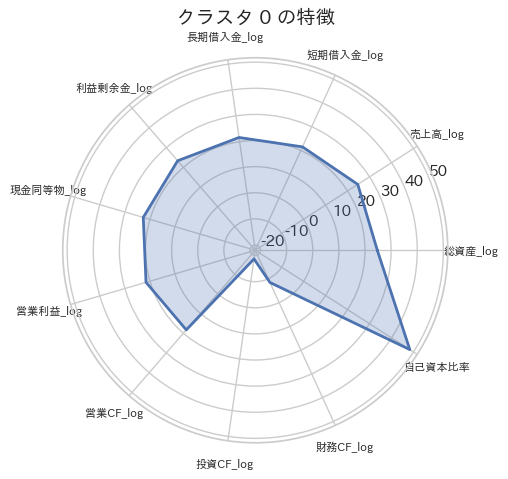

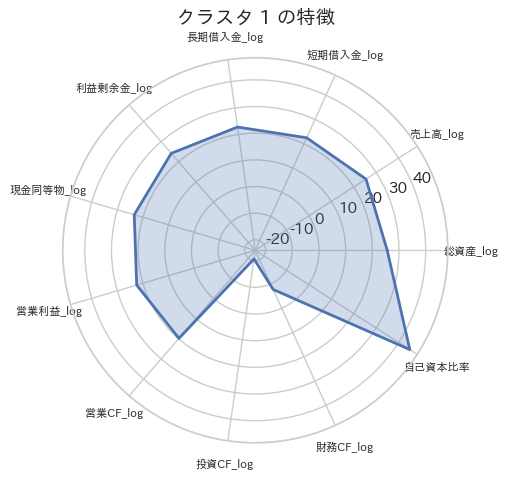

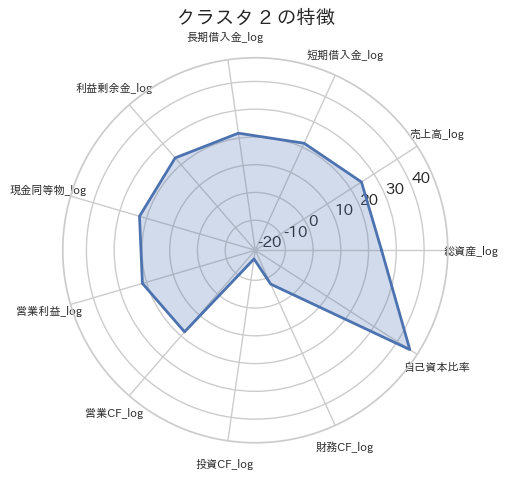

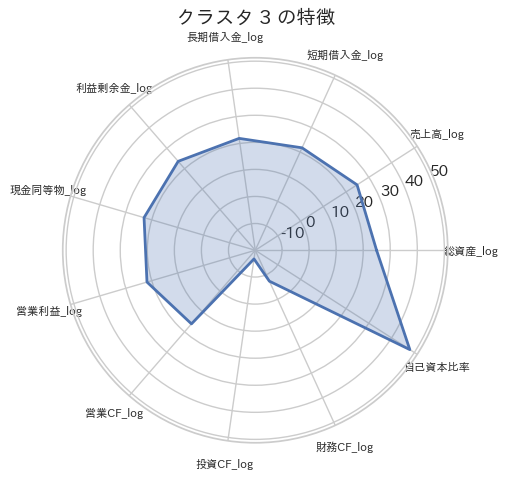

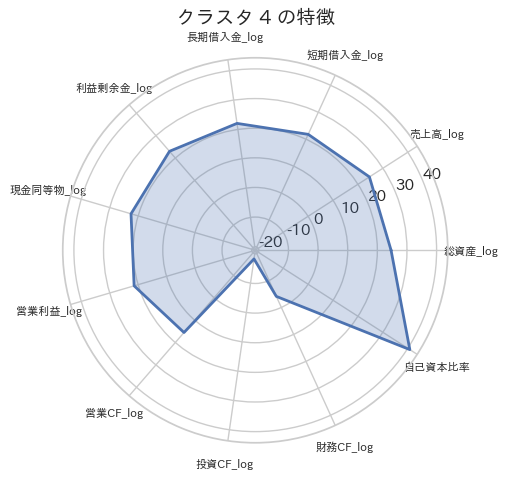

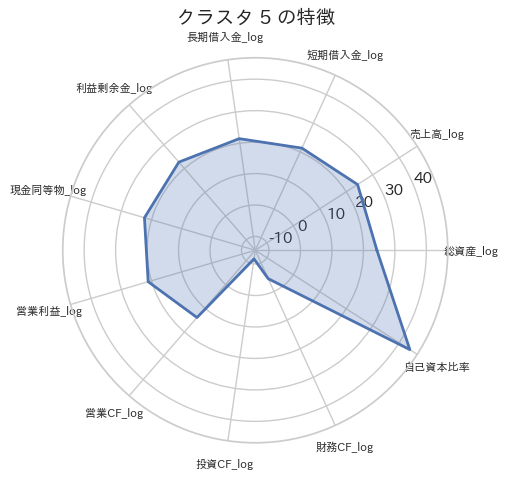

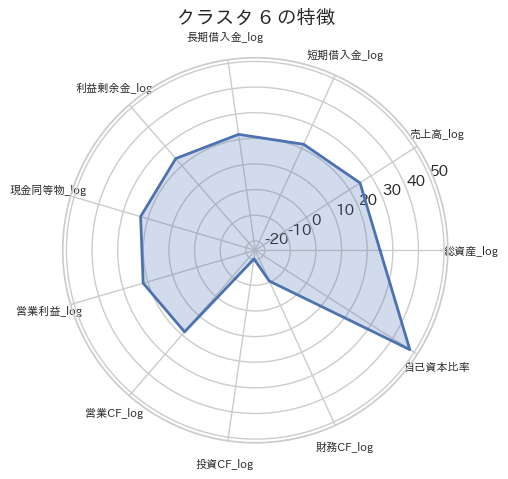

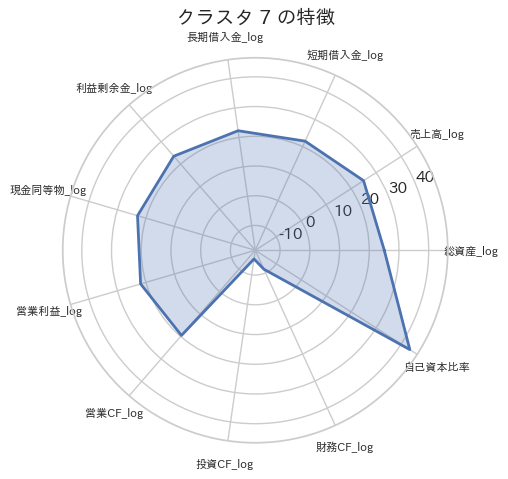

In [5]:
import matplotlib.pyplot as plt
import numpy as np

features = feature_cols
num_vars = len(features)

for c in sorted(df["cluster"].unique()):
    values = df[df["cluster"] == c][features].mean().values

    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    values = np.concatenate((values, [values[0]]))
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(polar=True))

    ax.plot(angles, values, linewidth=2)
    ax.fill(angles, values, alpha=0.25)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(features, fontsize=8)
    ax.set_title(f"クラスタ {c} の特徴", fontsize=14)
    plt.show()


In [3]:
# 前年クラスタ列の追加
df["cluster_prev"] = df.groupby("コード")["cluster"].shift(1)
df_trans = df.dropna(subset=["cluster_prev"]).copy()

df_trans.head()


,コード,年度,総資産_log,売上高_log,短期借入金_log,長期借入金_log,利益剰余金_log,現金同等物_log,営業利益_log,営業CF_log,投資CF_log,財務CF_log,自己資本比率,PC1,PC2,PC3,cluster_raw,cluster,cluster_prev
1,1301,2011,25.066097,25.815364,24.309614,22.010292,23.218040,21.923833,21.185741,-22.348380,-21.847221,22.902213,22.2,0.110753,-2.988445,2.594057,7,5,5.0
2,1301,2012,25.165176,25.926640,24.392070,21.751813,23.209588,21.958156,21.215520,-22.390406,-20.729248,22.584862,20.0,0.256286,-2.915507,-2.115750,3,3,5.0
3,1301,2013,25.145054,25.905308,23.867030,22.821652,23.276298,22.060633,21.566556,22.722581,-19.966113,-22.612454,22.1,0.897285,-0.759986,1.041931,7,4,3.0
4,1301,2014,25.157873,26.033448,23.705609,23.207922,23.450399,21.943210,21.793136,21.370369,-21.365120,-20.053835,23.4,0.871185,-0.675126,0.881310,5,7,4.0
5,1301,2015,25.211194,26.109365,23.792249,23.194243,23.528866,22.126909,21.623427,-21.573417,-20.451457,22.031058,25.5,0.531338,-3.066428,-0.283887,5,6,7.0


In [4]:
# 遷移行列の作成
transition_matrix = pd.crosstab(df_trans["cluster_prev"], df_trans["cluster"], normalize="index")

transition_matrix


cluster,0,1,2,3,4,5,6,7
cluster_prev,,,,,,,,
0.0,0.133144,0.168909,0.120751,0.233711,0.063031,0.059844,0.064802,0.155807
1.0,0.133522,0.143261,0.126924,0.073830,0.092994,0.040528,0.252592,0.136349
2.0,0.103755,0.075428,0.155468,0.166337,0.181159,0.089921,0.128458,0.099473
3.0,0.108159,0.225047,0.109677,0.105503,0.083112,0.075901,0.148767,0.143833
4.0,0.134629,0.144708,0.056156,0.042837,0.231821,0.154428,0.159107,0.076314
5.0,0.076289,0.196907,0.108763,0.113918,0.130928,0.167010,0.126289,0.079897
6.0,0.238978,0.101120,0.162701,0.096571,0.092372,0.092372,0.115115,0.100770
7.0,0.084656,0.134543,0.296296,0.082766,0.143235,0.081255,0.063492,0.113757


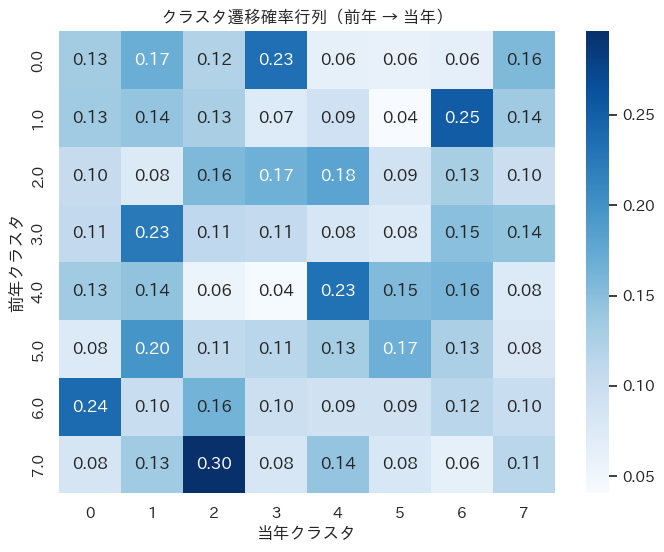

In [15]:
plt.figure(figsize=(8,6))
sns.heatmap(transition_matrix, annot=True, fmt=".2f", cmap="Blues")
plt.title("クラスタ遷移確率行列（前年 → 当年）")
plt.xlabel("当年クラスタ")
plt.ylabel("前年クラスタ")
plt.show()
